# UC00209: Land Use Efficiency Analysis

## Scenario
Melbourne consists of diverse land use zones including residential, commercial, and mixed-use areas. However, not all land is utilised with the same level of efficiency. Some areas are highly developed and support strong economic and population activity, while others remain underutilised.

This use case aims to analyse land use efficiency by integrating multiple datasets from the City of Melbourne Open Data platform. The goal is to identify patterns in land utilisation and provide insights to support urban planning and decision-making.

## Step 1: Data Collection and Initial Exploration
In this step, we connect to the City of Melbourne Open Data API and retrieve datasets required for analysis. We begin with the CLUE Small Areas dataset to understand the spatial structure of Melbourne.

In [1]:
import pandas as pd
import requests

def fetch_dataset(dataset_id, limit=1000):
    url = f"https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/{dataset_id}/records"
    params = {"limit": limit}
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()
    return pd.DataFrame(data.get("results", []))

### Load CLUE Small Areas Dataset
This dataset provides geographical divisions used for land use and employment analysis. It will act as the base structure for grouping and comparing land use efficiency.

In [3]:
small_areas = fetch_dataset(
    "small-areas-for-census-of-land-use-and-employment-clue",
    limit=50
)

small_areas.head()

,geo_point_2d,geo_shape,featurenam,shape_area,shape_len
0,"{'lon': 144.98292521995853, 'lat': -37.8376070...","{'type': 'Feature', 'geometry': {'coordinates'...",South Yarra,1057773.39715,5424.13644582
1,"{'lon': 144.96291513859617, 'lat': -37.8138110...","{'type': 'Feature', 'geometry': {'coordinates'...",Melbourne (CBD),2485904.89194,7112.60987105
2,"{'lon': 144.97838992382978, 'lat': -37.8287640...","{'type': 'Feature', 'geometry': {'coordinates'...",Melbourne (Remainder),2668300.95898,11399.6082458
3,"{'lon': 144.94506274103145, 'lat': -37.7984489...","{'type': 'Feature', 'geometry': {'coordinates'...",North Melbourne,2408377.21789,7546.64919141
4,"{'lon': 144.9221537804208, 'lat': -37.80962130...","{'type': 'Feature', 'geometry': {'coordinates'...",West Melbourne (Industrial),5917883.21599,11793.960449


### Inspect Dataset Structure
We examine the dataset to understand its variables and structure before cleaning and analysis.

In [4]:
print("Shape:", small_areas.shape)
print("\nColumns:")
print(small_areas.columns.tolist())

Shape: (13, 5)

Columns:
['geo_point_2d', 'geo_shape', 'featurenam', 'shape_area', 'shape_len']


### Data Cleaning – CLUE Small Areas

The CLUE Small Areas dataset contains spatial boundaries for Melbourne regions.  
To prepare the dataset for analysis, we:

- Select relevant columns  
- Rename columns for clarity  
- Remove unnecessary fields  

This cleaned dataset will be used as the base for merging other datasets.

In [5]:
# Select only relevant columns
areas_df = small_areas[["featurenam", "shape_area"]].copy()

# Rename columns for clarity
areas_df = areas_df.rename(columns={
    "featurenam": "area_name",
    "shape_area": "total_land_area"
})

# Check result
areas_df.head()

,area_name,total_land_area
0,South Yarra,1057773.39715
1,Melbourne (CBD),2485904.89194
2,Melbourne (Remainder),2668300.95898
3,North Melbourne,2408377.21789
4,West Melbourne (Industrial),5917883.21599


### Cleaned Dataset Overview

The dataset now contains:

- area_name → Name of the Melbourne region  
- total_land_area → Total land area of the region  

This will be used as the base for calculating land use efficiency.

### Load Floor Space Dataset

The floor space dataset provides floor space in square metres for CLUE blocks, classified by space use and small area allocation. This dataset is important because it helps estimate how intensely different areas are being developed and used.

In [8]:
import pandas as pd

floor_space_url = (
    "https://data.melbourne.vic.gov.au/explore/dataset/"
    "floor-space-by-use-by-block/download/?format=csv&timezone=Australia/Melbourne&lang=en"
)

floor_space = pd.read_csv(floor_space_url)
floor_space.head()

,census_year;block_id;clue_small_area;commercial_accommodation;common_area;community_use;educational_research;entertainment_recreation_indoor;equipment_installation;hospital_clinic;house_townhouse;institutional_accommodation;manufacturing;office;park_reserve;parking_commercial_covered;parking_commercial_uncovered;parking_private_covered;parking_private_uncovered;performances_conferences_ceremonies;private_outdoor_space;public_display_area;residential_apartment;retail_cars;retail_shop;retail_showroom;retail_stall;sports_and_recreation_outdoor;square_promenade;storage;student_accommodation;transport;transport_storage_uncovered;unoccupied_under_construction;unoccupied_under_demolition_condemned;unoccupied_under_renovation;unoccupied_undeveloped_site;unoccupied_unused;wholesale;workshop_studio;total_floor_space_in_block
0,2002;34;Melbourne (CBD);0;55832;0;0;2515;4251;...
1,2002;47;Melbourne (CBD);;6463;0;0;4407;0;;0;0;...
2,2002;116;Melbourne (CBD);0;;0;0;;0;;0;0;0;0;0;...
3,2002;220;Carlton;0;;0;0;0;0;0;7877;0;0;;0;0;0;...
4,2002;256;Carlton;;;;0;0;0;0;0;0;0;11782;0;0;0;...


In [9]:
print("Shape:", floor_space.shape)
print("\nColumns:")
print(floor_space.columns.tolist())

Shape: (13519, 1)

Columns:
['census_year;block_id;clue_small_area;commercial_accommodation;common_area;community_use;educational_research;entertainment_recreation_indoor;equipment_installation;hospital_clinic;house_townhouse;institutional_accommodation;manufacturing;office;park_reserve;parking_commercial_covered;parking_commercial_uncovered;parking_private_covered;parking_private_uncovered;performances_conferences_ceremonies;private_outdoor_space;public_display_area;residential_apartment;retail_cars;retail_shop;retail_showroom;retail_stall;sports_and_recreation_outdoor;square_promenade;storage;student_accommodation;transport;transport_storage_uncovered;unoccupied_under_construction;unoccupied_under_demolition_condemned;unoccupied_under_renovation;unoccupied_undeveloped_site;unoccupied_unused;wholesale;workshop_studio;total_floor_space_in_block']


In [10]:
floor_space = pd.read_csv(
    floor_space_url,
    sep=';',
    encoding='utf-8',
    engine='python'
)

floor_space.head()

,census_year,block_id,clue_small_area,commercial_accommodation,common_area,community_use,educational_research,entertainment_recreation_indoor,equipment_installation,hospital_clinic,...,transport,transport_storage_uncovered,unoccupied_under_construction,unoccupied_under_demolition_condemned,unoccupied_under_renovation,unoccupied_undeveloped_site,unoccupied_unused,wholesale,workshop_studio,total_floor_space_in_block
0,2002,34,Melbourne (CBD),0.0,55832.0,0.0,0.0,2515.0,4251.0,687.0,...,0.0,0.0,0.0,0.0,23945.0,0.0,24571.0,NaN,299.0,247631.0
1,2002,47,Melbourne (CBD),NaN,6463.0,0.0,0.0,4407.0,0.0,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,985.0,0.0,NaN,52005.0
2,2002,116,Melbourne (CBD),0.0,NaN,0.0,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6258.0
3,2002,220,Carlton,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,12598.0
4,2002,256,Carlton,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN,25408.0


In [11]:
print("Shape:", floor_space.shape)
print("\nColumns:")
print(floor_space.columns.tolist())

Shape: (13519, 41)

Columns:
['census_year', 'block_id', 'clue_small_area', 'commercial_accommodation', 'common_area', 'community_use', 'educational_research', 'entertainment_recreation_indoor', 'equipment_installation', 'hospital_clinic', 'house_townhouse', 'institutional_accommodation', 'manufacturing', 'office', 'park_reserve', 'parking_commercial_covered', 'parking_commercial_uncovered', 'parking_private_covered', 'parking_private_uncovered', 'performances_conferences_ceremonies', 'private_outdoor_space', 'public_display_area', 'residential_apartment', 'retail_cars', 'retail_shop', 'retail_showroom', 'retail_stall', 'sports_and_recreation_outdoor', 'square_promenade', 'storage', 'student_accommodation', 'transport', 'transport_storage_uncovered', 'unoccupied_under_construction', 'unoccupied_under_demolition_condemned', 'unoccupied_under_renovation', 'unoccupied_undeveloped_site', 'unoccupied_unused', 'wholesale', 'workshop_studio', 'total_floor_space_in_block']


### Aggregate Floor Space by Area

To measure land use efficiency, we aggregate total floor space for each area.  
This represents how much built infrastructure exists in each region.

In [12]:
# Select required columns
floor_df = floor_space[[
    "clue_small_area",
    "total_floor_space_in_block"
]].copy()

# Convert to numeric
floor_df["total_floor_space_in_block"] = pd.to_numeric(
    floor_df["total_floor_space_in_block"], errors="coerce"
)

# Drop missing values
floor_df = floor_df.dropna()

# Aggregate
floor_agg = (
    floor_df.groupby("clue_small_area")["total_floor_space_in_block"]
    .sum()
    .reset_index()
)

# Rename
floor_agg = floor_agg.rename(columns={
    "clue_small_area": "area_name",
    "total_floor_space_in_block": "total_floor_space"
})

floor_agg.head()

,area_name,total_floor_space
0,Carlton,76982951.0
1,Docklands,91643466.0
2,East Melbourne,53884546.0
3,Kensington,74097972.0
4,Melbourne (CBD),269837067.0


### Merge Land Area and Floor Space

We combine total land area with total floor space to calculate land use efficiency.

In [13]:
merged_df = areas_df.merge(
    floor_agg,
    on="area_name",
    how="inner"
)

merged_df.head()

,area_name,total_land_area,total_floor_space
0,South Yarra,1057773.39715,26730509.0
1,Melbourne (CBD),2485904.89194,269837067.0
2,Melbourne (Remainder),2668300.95898,61725177.0
3,North Melbourne,2408377.21789,52363269.0
4,West Melbourne (Industrial),5917883.21599,93610913.0


### Land Use Efficiency Calculation

We calculate land use efficiency as the ratio of built floor space to total land area.

In [15]:
merged_df["total_land_area"] = pd.to_numeric(
    merged_df["total_land_area"], errors="coerce"
)
merged_df = merged_df.dropna(subset=["total_land_area"])

merged_df["efficiency"] = (
    merged_df["total_floor_space"] /
    merged_df["total_land_area"]
)

merged_df.sort_values("efficiency", ascending=False).head()

,area_name,total_land_area,total_floor_space,efficiency
1,Melbourne (CBD),2.485905e+06,269837067.0,108.546818
9,Southbank,1.596010e+06,89729566.0,56.221169
6,Docklands,2.856029e+06,91643466.0,32.087726
7,Carlton,2.724821e+06,76982951.0,28.252482
10,East Melbourne,1.909073e+06,53884546.0,28.225508


### Top 5 Areas by Land Use Efficiency

This chart highlights the most efficient areas in Melbourne based on the ratio of total floor space to land area.

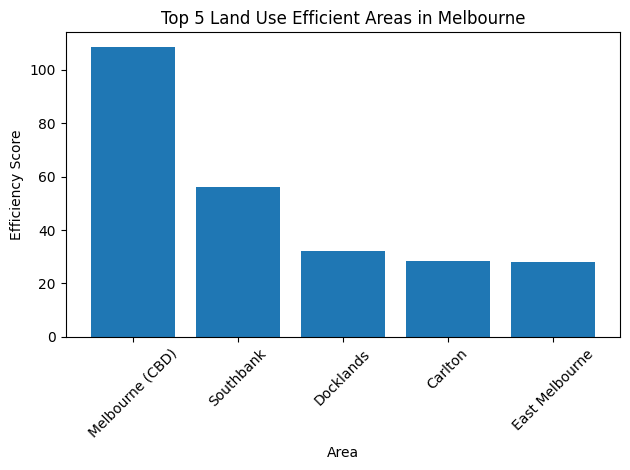

In [17]:
top5 = merged_df.sort_values("efficiency", ascending=False).head(5)

plt.figure()
plt.bar(top5["area_name"], top5["efficiency"])
plt.xticks(rotation=45)
plt.title("Top 5 Land Use Efficient Areas in Melbourne")
plt.xlabel("Area")
plt.ylabel("Efficiency Score")
plt.tight_layout()
plt.show()

The results show that Melbourne (CBD) has the highest land use efficiency by a significant margin, with an efficiency score exceeding 100. This indicates an extremely high concentration of built infrastructure relative to land area, reflecting the CBD’s role as the primary commercial and economic hub of Melbourne.

Southbank also demonstrates high efficiency, suggesting dense urban development with a mix of residential and commercial infrastructure. Docklands and Carlton follow with moderate efficiency levels, indicating well-developed but less densely utilised areas compared to the CBD.

These findings highlight how central urban areas are designed to maximise land usage, while surrounding areas show a more balanced distribution between built infrastructure and available space. The variation in efficiency scores reflects differences in zoning, land use purpose, and urban planning strategies across Melbourne.

### Least Efficient Areas

This analysis identifies areas with lower land use efficiency, which may indicate underutilised land or low-density development.

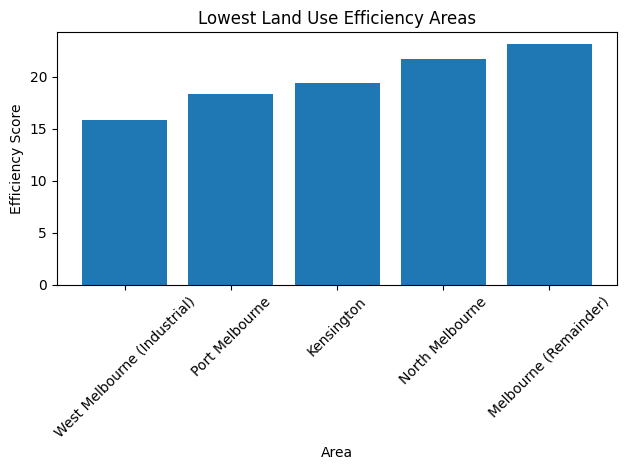

,area_name,total_land_area,total_floor_space,efficiency
4,West Melbourne (Industrial),5.917883e+06,93610913.0,15.818310
5,Port Melbourne,5.470093e+06,100546894.0,18.381204
11,Kensington,3.808797e+06,74097972.0,19.454427
3,North Melbourne,2.408377e+06,52363269.0,21.742138
2,Melbourne (Remainder),2.668301e+06,61725177.0,23.132764


In [18]:
bottom5 = merged_df.sort_values("efficiency", ascending=True).head(5)

plt.figure()
plt.bar(bottom5["area_name"], bottom5["efficiency"])
plt.xticks(rotation=45)
plt.title("Lowest Land Use Efficiency Areas")
plt.xlabel("Area")
plt.ylabel("Efficiency Score")
plt.tight_layout()
plt.show()

bottom5

The areas with the lowest efficiency scores represent regions where the ratio of built floor space to land area is relatively low. This may indicate underutilised land, industrial zones, or areas designated for non-dense activities such as parks, infrastructure, or low-density housing.

These findings do not necessarily imply poor land use but rather highlight different planning priorities. Some areas may intentionally maintain lower density to support environmental sustainability, liveability, or future development potential.

### Analysis: Land Area vs Floor Space

The scatter plot illustrates the relationship between total land area and total floor space across different regions in Melbourne. The results indicate that there is no strong linear relationship between land size and floor space.

Notably, Melbourne (CBD) appears as a clear outlier with significantly higher floor space compared to its land area. This reflects its role as the central business district, where land is utilised intensively through vertical development and high-density infrastructure.

Other areas with relatively large land sizes do not necessarily show equally high floor space, suggesting that land size alone does not determine development intensity. Instead, zoning regulations, economic activity, and urban planning strategies play a critical role in shaping land use efficiency.

Overall, the graph demonstrates that highly efficient land use is concentrated in specific urban zones rather than being evenly distributed across Melbourne.

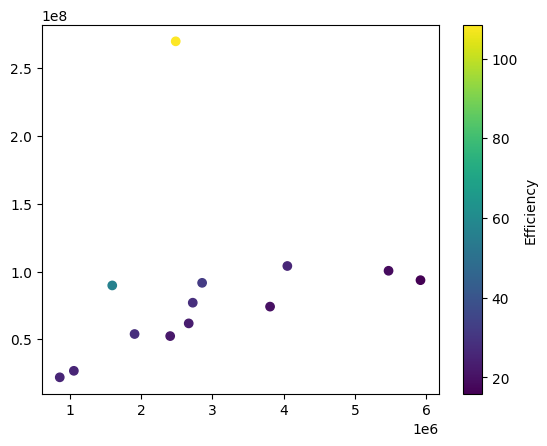

In [22]:
plt.scatter(
    merged_df["total_land_area"],
    merged_df["total_floor_space"],
    c=merged_df["efficiency"]
)
plt.colorbar(label="Efficiency")

### Load Population Dataset

This dataset represents the number of residents in each area.  
It helps evaluate how land use efficiency relates to population density and urban activity.

In [24]:
population_url = (
    "https://data.melbourne.vic.gov.au/explore/dataset/"
    "residents-profiles-by-clue-small-area/download/?format=csv"
)

population = pd.read_csv(population_url, sep=';')
population.head()

,geography,year,topic,category,sub_category,value_description,value
0,Docklands,2011,Households: Dwellings,Dwelling type - detailed,Flat or apartment - In a three storey block,Count of occupied private dwellings,0.0
1,East Melbourne,2011,Households: Dwellings,Dwelling type - detailed,"Semi-detached, row or terrace house, townhouse...",Count of occupied private dwellings,118.0
2,Greater Melbourne,2011,Households: Dwellings,Dwelling type - detailed,Flat or apartment - Attached to a house,Count of occupied private dwellings,1104.0
3,Melbourne (CBD),2011,Households: Dwellings,Dwelling type - detailed,"Other dwelling - Caravan, cabin or houseboat",Count of occupied private dwellings,0.0
4,Parkville,2011,Households: Dwellings,Dwelling type - detailed,Dwelling structure not stated,Count of occupied private dwellings,0.0


In [25]:
print("Shape:", population.shape)
print("\nColumns:")
print(population.columns.tolist())

Shape: (10776, 7)

Columns:
['geography', 'year', 'topic', 'category', 'sub_category', 'value_description', 'value']


### Extract Population Data

The dataset contains multiple demographic categories.  
We filter the dataset to extract only total population values for each area.

In [29]:
# Filter ONLY total population
pop_df = population[
    population["value_description"] == "Count of persons"
].copy()

pop_df.head()

,geography,year,topic,category,sub_category,value_description,value
43,Carlton,2011,Residents: Age and gender,Age - 10 year groups,60-69 years,Count of persons,651.0
44,Docklands,2011,Residents: Age and gender,Age - 10 year groups,20-29 years,Count of persons,1861.0
45,Kensington,2011,Residents: Age and gender,Age - 10 year groups,20-29 years,Count of persons,2510.0
46,Southbank,2011,Residents: Age and gender,Age - 10 year groups,60-69 years,Count of persons,613.0
47,Southbank,2011,Residents: Age and gender,Age - 10 year groups,90 years and over,Count of persons,4.0


In [30]:
# Check available years
print(pop_df["year"].unique())

[2011 2016]


### Selecting the Latest Population Data

The dataset contains population data for multiple years (2011 and 2016).  
To ensure the analysis reflects the most recent trends, we select data from 2016.

In [32]:
pop_df = pop_df[pop_df["year"] == 2016]

### Aggregate Population by Area

We aggregate the population values for each area to calculate total population.  
This allows us to compare population distribution across different regions in Melbourne.

In [33]:
pop_df["value"] = pd.to_numeric(pop_df["value"], errors="coerce")

pop_df = pop_df.dropna()

pop_agg = (
    pop_df.groupby("geography")["value"]
    .sum()
    .reset_index()
)

pop_agg = pop_agg.rename(columns={
    "geography": "area_name",
    "value": "population"
})

pop_agg.head()

,area_name,population
0,Carlton,246278.0
1,City of Melbourne,1768818.0
2,Docklands,142375.0
3,East Melbourne,61392.0
4,Greater Melbourne,58418537.0


In [34]:
merged_df = merged_df.merge(
    pop_agg,
    on="area_name",
    how="left"
)

### Multi-Factor Land Use Metrics

To enhance the analysis, we calculate:

- Population density → number of people per land area  
- Smart efficiency score → combines land use efficiency and population density  

This provides a more comprehensive measure of urban land use.

In [35]:
merged_df["population_density"] = (
    merged_df["population"] / merged_df["total_land_area"]
)

merged_df["smart_efficiency"] = (
    0.6 * merged_df["efficiency"] +
    0.4 * merged_df["population_density"]
)

### Multi-Factor Land Use Analysis (2016)

This visualisation combines multiple variables:

- X-axis → Total land area  
- Y-axis → Total floor space  
- Bubble size → Population  

This allows us to understand how land use efficiency varies across Melbourne when population is considered.

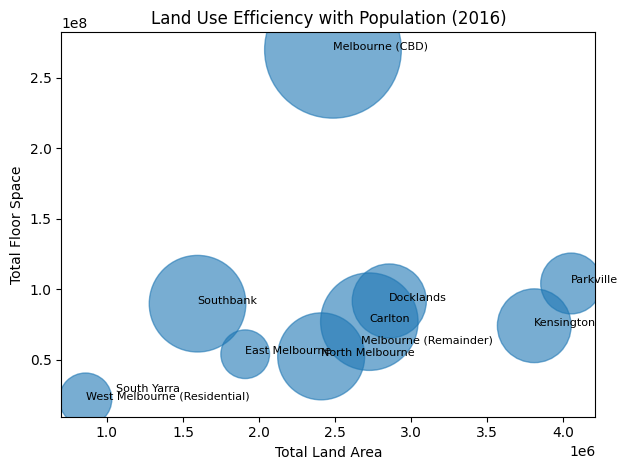

In [36]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    merged_df["total_land_area"],
    merged_df["total_floor_space"],
    s=merged_df["population"] / 50,
    alpha=0.6
)

for i, txt in enumerate(merged_df["area_name"]):
    plt.annotate(txt,
                 (merged_df["total_land_area"][i],
                  merged_df["total_floor_space"][i]),
                 fontsize=8)

plt.title("Land Use Efficiency with Population (2016)")
plt.xlabel("Total Land Area")
plt.ylabel("Total Floor Space")
plt.tight_layout()
plt.show()

### Discussion

The inclusion of population data provides a deeper understanding of land use efficiency across Melbourne. While earlier analysis focused on the relationship between floor space and land area, adding population reveals how intensively these areas are utilised by residents.

Melbourne (CBD) remains the most efficient area, combining high floor space with a dense population. This reflects its role as the central hub of economic and residential activity. Areas such as Southbank and Docklands also demonstrate strong efficiency, indicating well-developed urban environments.

In contrast, areas with lower population density relative to land area show reduced utilisation. These may represent industrial zones, open spaces, or areas with lower development intensity.

Overall, this multi-factor approach highlights that land use efficiency is influenced by both infrastructure and human activity. This provides valuable insights for urban planners to identify opportunities for redevelopment, optimisation, and sustainable growth.